In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [5]:
sales=pd.read_csv('Advertising.csv')

In [7]:
sales.drop(columns='Unnamed: 0',inplace=True)

In [9]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [10]:
sales.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


# EDA

# Distribution of each feature

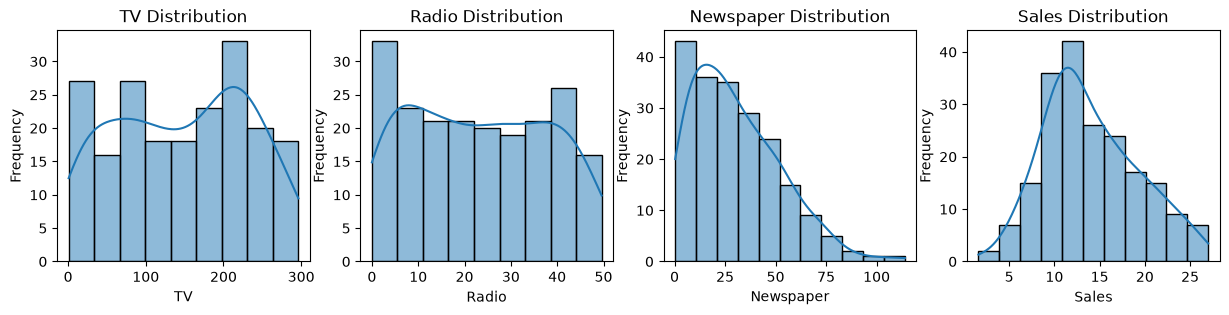

In [25]:
fig,ax=plt.subplots(1,4,figsize=(15,3))
for i,col in enumerate(sales.columns):
    sns.histplot(sales[col],kde=True,ax=ax[i])
    ax[i].set_title(f'{col} Distribution')
    ax[i].set_xlabel(col)
    ax[i].set_ylabel('Frequency')

plt.show()

# Using boxplot to detect outliers if there is any:

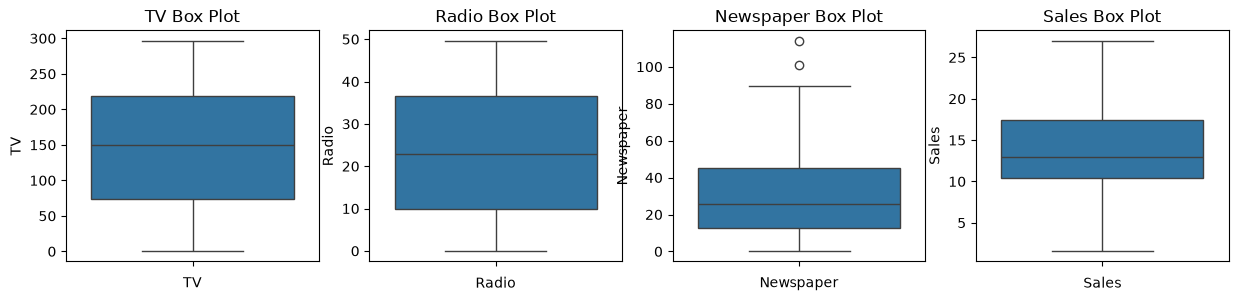

In [27]:
fig,ax=plt.subplots(1,4,figsize=(15,3))
for i,col in enumerate(sales.columns):
    sns.boxplot(sales[col],ax=ax[i])
    ax[i].set_title(f'{col} Box Plot')
    ax[i].set_xlabel(col)

plt.show()

# Scatter plots: Feature vs Sales

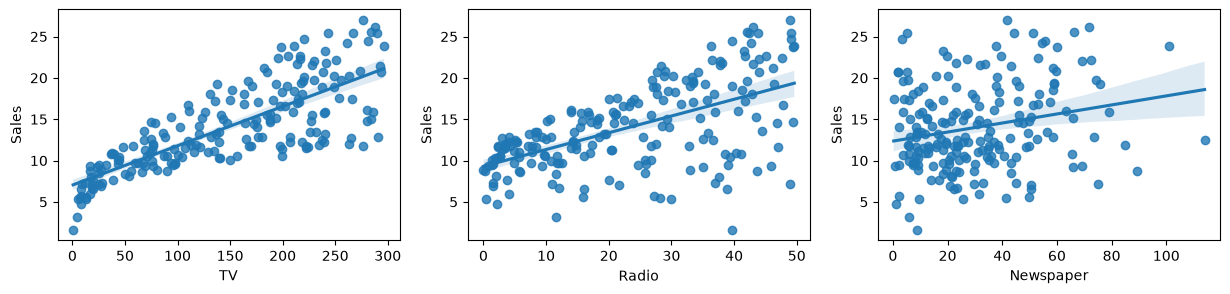

In [35]:
features=sales.columns[:-1]
target=sales.columns[-1]

fig,ax=plt.subplots(1,3,figsize=(15,3))
for i,col in enumerate(features):
    sns.regplot(x=sales[col],y=sales[target],ax=ax[i])
    ax[i].set_xlabel(col)
    ax[i].set_ylabel(target)


# Correlation Matrix: To find correlation between features and target

In [45]:
corr_matrix=sales.corr()

<Axes: >

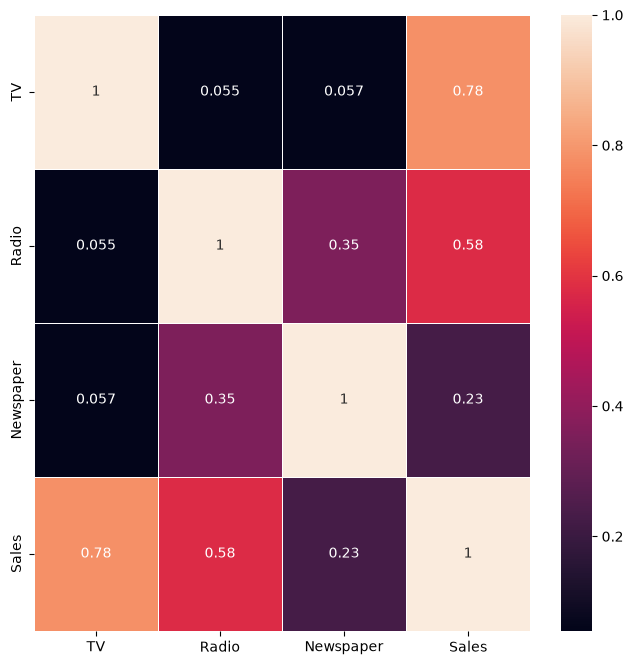

In [54]:
plt.figure(figsize=(8,8))
sns.heatmap(corr_matrix,annot=True,linewidth=0.5)

### Pair Plot for a comprehensive view

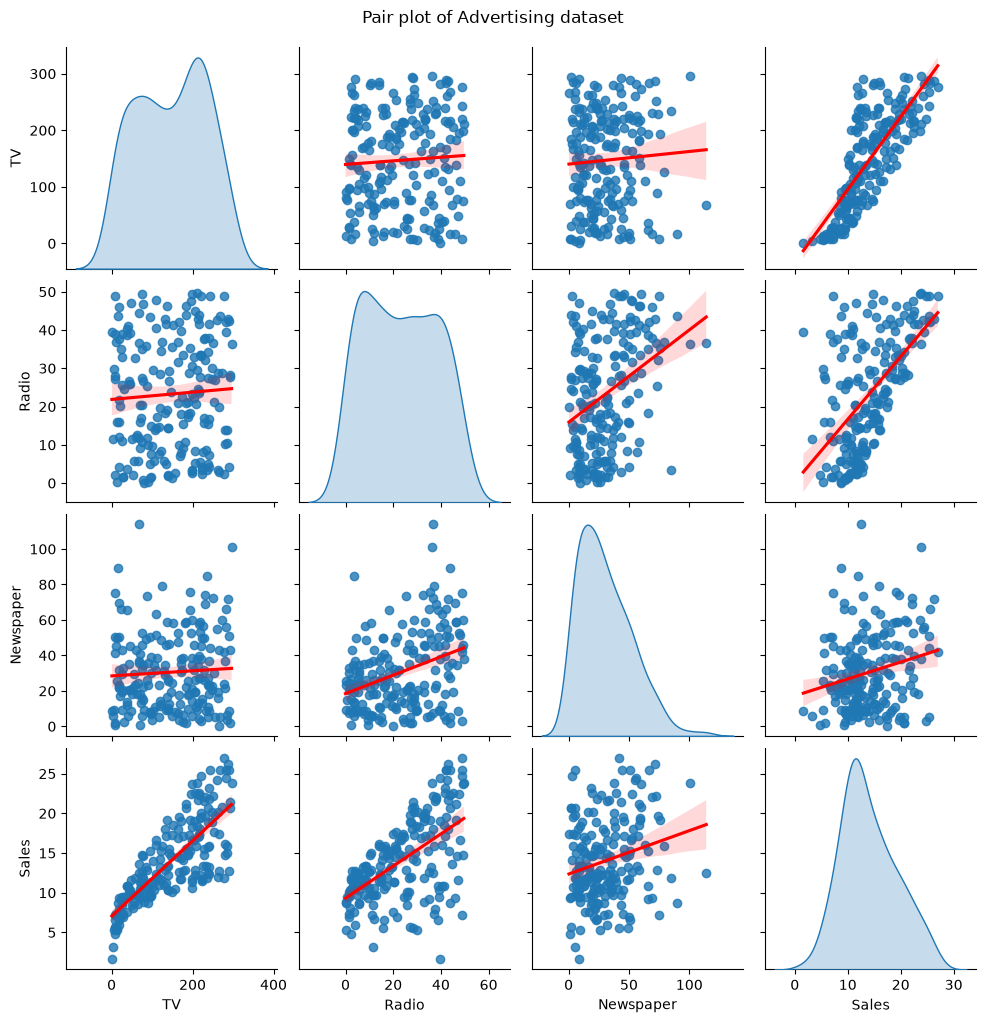

In [123]:
sns.pairplot(sales,kind='reg',diag_kind='kde',plot_kws={'line_kws':{'color':'red'}})
plt.suptitle('Pair plot of Advertising dataset',y=1.02)
plt.show()

# Let's Build the Model

### Simple Linear Regression

In [55]:
X=sales.iloc[:,:-1]
y=sales.iloc[:,-1]

### Let's split it into train-test

In [83]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

### Now we will train the model

In [95]:
slr=LinearRegression()
slr.fit(X_train[['TV']],y_train)
y_pred=slr.predict(X_test[['TV']])

### Let's check the best fit line for train set

<Axes: xlabel='TV', ylabel='Sales'>

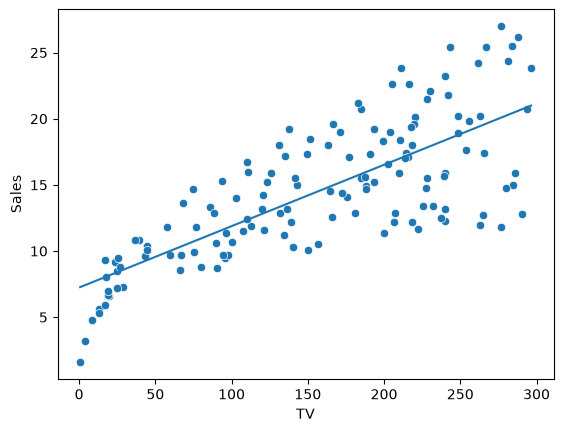

In [96]:
sns.scatterplot(x=X_train['TV'],y=y_train)
sns.lineplot(x=X_train['TV'],y=slr.intercept_ + slr.coef_[0]*X_train['TV'])

### Now let's evaluate the model on test set

In [110]:
MSE=mean_squared_error(y_test,y_pred)
MAE=mean_absolute_error(y_test,y_pred)
R2_Score=r2_score(y_test,y_pred)

print('RMSE: ',np.sqrt(MSE))
print('MAE: ',MAE)
print('R2 Score: ',R2_Score)

RMSE:  2.9951613049072354
MAE:  2.2758809050205113
R2 Score:  0.6714477229302764


# Multiple Linear Regression

In [109]:
mlr=LinearRegression()
mlr.fit(X_train,y_train)
mlr_y_pred=mlr.predict(X_test)

print('Multiple Linear Regression Coefficients')
print(f"Intercept (beta_0): {mlr.intercept_}")

for i,col in enumerate(X.columns):
    print(f"Coefficient for {col} (beta_{i+1}): {mlr.coef_[i]:.4f} ")

Multiple Linear Regression Coefficients
Intercept (beta_0): 2.7089490925159065
Coefficient for TV (beta_1): 0.0441 
Coefficient for Radio (beta_2): 0.1993 
Coefficient for Newspaper (beta_3): 0.0069 


### Model Evaluation

In [111]:
MSE=mean_squared_error(y_test,mlr_y_pred)
MAE=mean_absolute_error(y_test,mlr_y_pred)
R2_Score=r2_score(y_test,mlr_y_pred)

print('RMSE: ',np.sqrt(MSE))
print('MAE: ',MAE)
print('R2 Score: ',R2_Score)

RMSE:  1.9485372043446387
MAE:  1.5116692224549086
R2 Score:  0.8609466508230368


### Actual vs Predicted Sales

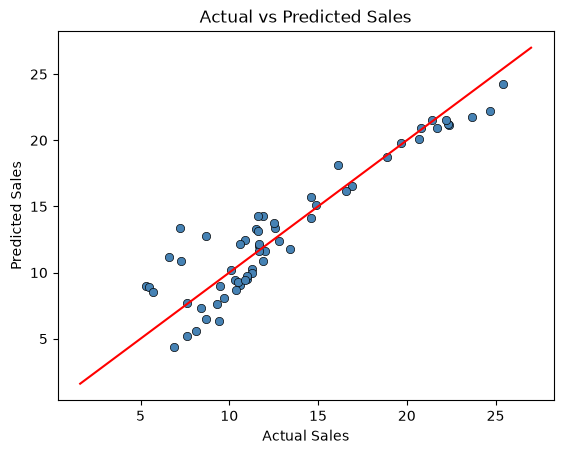

In [117]:
sns.scatterplot(x=y_test,y=mlr_y_pred,color='steelblue',edgecolor='black')
sns.lineplot(x=[y.min(),y.max()],y=[y.min(),y.max()],color='red')
plt.title('Actual vs Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_28492\3603728543.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X.columns,y=mlr.coef_,palette='viridis')


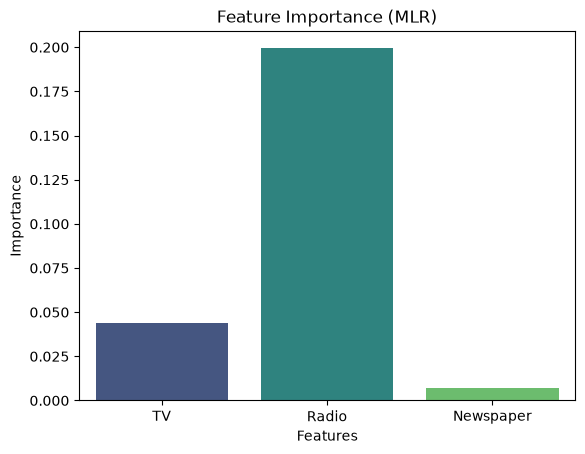

In [120]:
sns.barplot(x=X.columns,y=mlr.coef_,palette='viridis')
plt.title('Feature Importance (MLR)')
plt.xlabel('Features')
plt.ylabel('Importance')

plt.show()